In [8]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
import numpy as np
import matplotlib.pyplot as plt
import datetime

# qiskit-algorithms >= 0.4 only accepts V2 samplers, whose circuits must be transpiled first.
# Pass `transpiler=pm` to QAOA, and use `ansatz=pm.run(ansatz)` for SamplingVQE.
pm = generate_preset_pass_manager(optimization_level=1, backend=AerSimulator())

In [9]:
# set number of assets (= number of qubits)
num_assets = 4
seed = 123

# Generate expected return and covariance matrix from (random) time-series
stocks = [("TICKER%s" % i) for i in range(num_assets)]
data = RandomDataProvider(
    tickers=stocks,
    start=datetime.datetime(2016, 1, 1),
    end=datetime.datetime(2016, 1, 30),
    seed=seed,
)
data.run()
mu = data.get_period_return_mean_vector()
sigma = data.get_period_return_covariance_matrix()

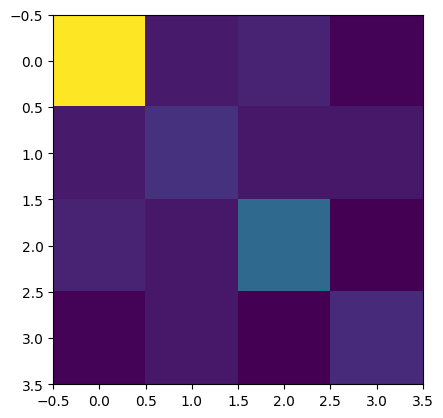

In [10]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()

In [11]:
q = 0.5  # set risk factor
budget = num_assets // 2  # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 0.001270694296030004*x_0^2 + 7.34022166934733e-05*..., 4 variables, 1 constraints, 'Portfolio optimization'>

In [12]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    eigenstate = result.min_eigen_solver_result.eigenstate
    if isinstance(eigenstate, QuasiDistribution):
        probabilities = eigenstate.binary_probabilities()
    elif isinstance(eigenstate, dict):
        probabilities = eigenstate  # V2 samplers: {"1001": 0.60, ...}
    else:
        probabilities = {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

In [13]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

result = exact_eigensolver.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		1.0000


In [14]:
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=500)
ry = TwoLocal(num_assets, "ry", "cz", reps=3, entanglement="full")
# Transpile the ansatz so the Aer SamplerV2 can run it (otherwise: "unknown instruction: TwoLocal")
svqe_mes = SamplingVQE(sampler=Sampler(), ansatz=pm.run(ry), optimizer=cobyla)
svqe = MinimumEigenOptimizer(svqe_mes)
result = svqe.solve(qp)

print_result(result)

C:\Users\giuse\AppData\Local\Temp\ipykernel_44900\138573237.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ry = TwoLocal(num_assets, "ry", "cz", reps=3, entanglement="full")


Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		0.7549
 [0 1 1 0]	0.0008		0.1055
 [1 0 1 0]	-0.0140		0.0371
 [0 0 1 1]	-0.0010		0.0293
 [1 1 1 0]	-0.0130		0.0234
 [1 0 1 1]	-0.0150		0.0225
 [0 0 1 0]	-0.0001		0.0127
 [1 1 0 0]	-0.0130		0.0059
 [0 1 1 1]	-0.0000		0.0049
 [0 0 0 1]	-0.0008		0.0029
 [0 1 0 1]	0.0002		0.0010


In [15]:
algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=250)
# `transpiler=pm` lets the Aer SamplerV2 run the QAOA circuit
qaoa_mes = QAOA(sampler=Sampler(), optimizer=cobyla, reps=3, transpiler=pm)
qaoa = MinimumEigenOptimizer(qaoa_mes)
result = qaoa.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		0.1475
 [0 0 1 1]	-0.0010		0.1465
 [0 1 0 1]	0.0002		0.1416
 [0 1 1 0]	0.0008		0.1328
 [1 0 1 0]	-0.0140		0.1318
 [1 1 0 0]	-0.0130		0.1299
 [1 1 1 0]	-0.0130		0.0283
 [0 1 1 1]	-0.0000		0.0244
 [0 0 1 0]	-0.0001		0.0225
 [1 0 1 1]	-0.0150		0.0176
 [0 1 0 0]	0.0009		0.0176
 [0 0 0 1]	-0.0008		0.0156
 [1 1 0 1]	-0.0139		0.0137
 [1 0 0 0]	-0.0140		0.0117
 [0 0 0 0]	0.0000		0.0117
 [1 1 1 1]	-0.0139		0.0068
